# Import Libraries and Dependencies

Loading essential dependencies for data processing, interactive visualization, and machine learning. This setup covers the entire lifecycle of the project, from unsupervised clustering and dimensionality reduction (PCA) to supervised classification and automated pipeline construction.

In [1]:
import gdown
import pandas as pd
import numpy as np
import math
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import os
import joblib
import matplotlib.ticker as mtick
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import GridSearchCV
import shap
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

- Data Handling & OS: pandas, numpy, and gdown for data manipulation and file acquisition.

- Visualization: matplotlib, seaborn, and plotly for creating both static and interactive insights.

- Preprocessing & Feature Engineering: sklearn.preprocessing, impute, and ColumnTransformer to handle data cleaning and transformations.

- Clustering (Unsupervised): KMeans and Yellowbrick for cluster discovery and evaluation.

- Classification (Supervised): DecisionTree, RandomForest, and XGBoost for building predictive models.

- Model Tuning & Evaluation: GridSearchCV and various metrics to optimize and validate model performance.

- Pipeline & Persistence: Pipeline for streamlining the workflow and joblib for model export.

- Interpretability: shap for explaining model predictions.

Setting pandas to display all columns without truncation for better data inspection and feature analysis.

In [2]:
pd.set_option('display.max_columns', None)

Suppressing Python and library warnings to keep the notebook outputs neat and focused on the actual results.

In [3]:
import warnings
warnings.filterwarnings('ignore')

# Data Loading

Downloads the raw bank transactions dataset directly from Google Drive and loads it into a pandas DataFrame for analysis.

In [4]:
file_id = '163av8kALAjxoV2ZneEG5NGsHCE6Iqvj2'
if not os.path.exists('datas'):
  os.makedirs('datas')
output_path = 'datas/bank_transactions.csv'
gdown.download(f'https://drive.google.com/uc?id={file_id}', output_path, quiet=False)

df = pd.read_csv(output_path)

Downloading...
From: https://drive.google.com/uc?id=163av8kALAjxoV2ZneEG5NGsHCE6Iqvj2
To: /content/datas/bank_transactions.csv
100%|██████████| 363k/363k [00:00<00:00, 38.0MB/s]


Previews the first 5 rows of the dataset to quickly inspect the data structure and feature values.

In [5]:
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,198.0,1.0,7429.40,2024-11-04 08:06:39


Provides a concise summary of the dataframe, including data types, memory usage, and non-null counts.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2537 entries, 0 to 2536
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2508 non-null   object 
 1   AccountID                2516 non-null   object 
 2   TransactionAmount        2511 non-null   float64
 3   TransactionDate          2509 non-null   object 
 4   TransactionType          2507 non-null   object 
 5   Location                 2507 non-null   object 
 6   DeviceID                 2507 non-null   object 
 7   IP Address               2517 non-null   object 
 8   MerchantID               2514 non-null   object 
 9   Channel                  2510 non-null   object 
 10  CustomerAge              2519 non-null   float64
 11  CustomerOccupation       2514 non-null   object 
 12  TransactionDuration      2511 non-null   float64
 13  LoginAttempts            2516 non-null   float64
 14  AccountBalance          

Generates descriptive statistics to understand the central tendency, dispersion, and shape of the numerical features.

In [7]:
df.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2511.000000,2519.000000,2511.000000,2516.000000,2510.000000
mean,297.656468,44.678444,119.422939,1.121622,5113.438124
std,292.230367,17.837359,70.078513,0.594469,3897.975861
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.310000,27.000000,63.000000,1.000000,1504.727500
50%,211.360000,45.000000,112.000000,1.000000,4734.110000
75%,413.105000,59.000000,161.000000,1.000000,7672.687500
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


# Data Understanding / Exploratory Data Analysis (EDA)

## Check Duplicates

Calculates the total number of identical rows in the dataset to check for data redundancy.

In [8]:
df.duplicated().sum()

np.int64(21)

## Check Missing Values

Counts the number of null or missing values in each column to determine where data imputation is needed.

In [9]:
df.isnull().sum()

,0
TransactionID,29
AccountID,21
TransactionAmount,26
TransactionDate,28
TransactionType,30
Location,30
DeviceID,30
IP Address,20
MerchantID,23
Channel,27


## Check Outliers

Generates box plots for all numerical features to visually inspect the presence of outliers and data spread.

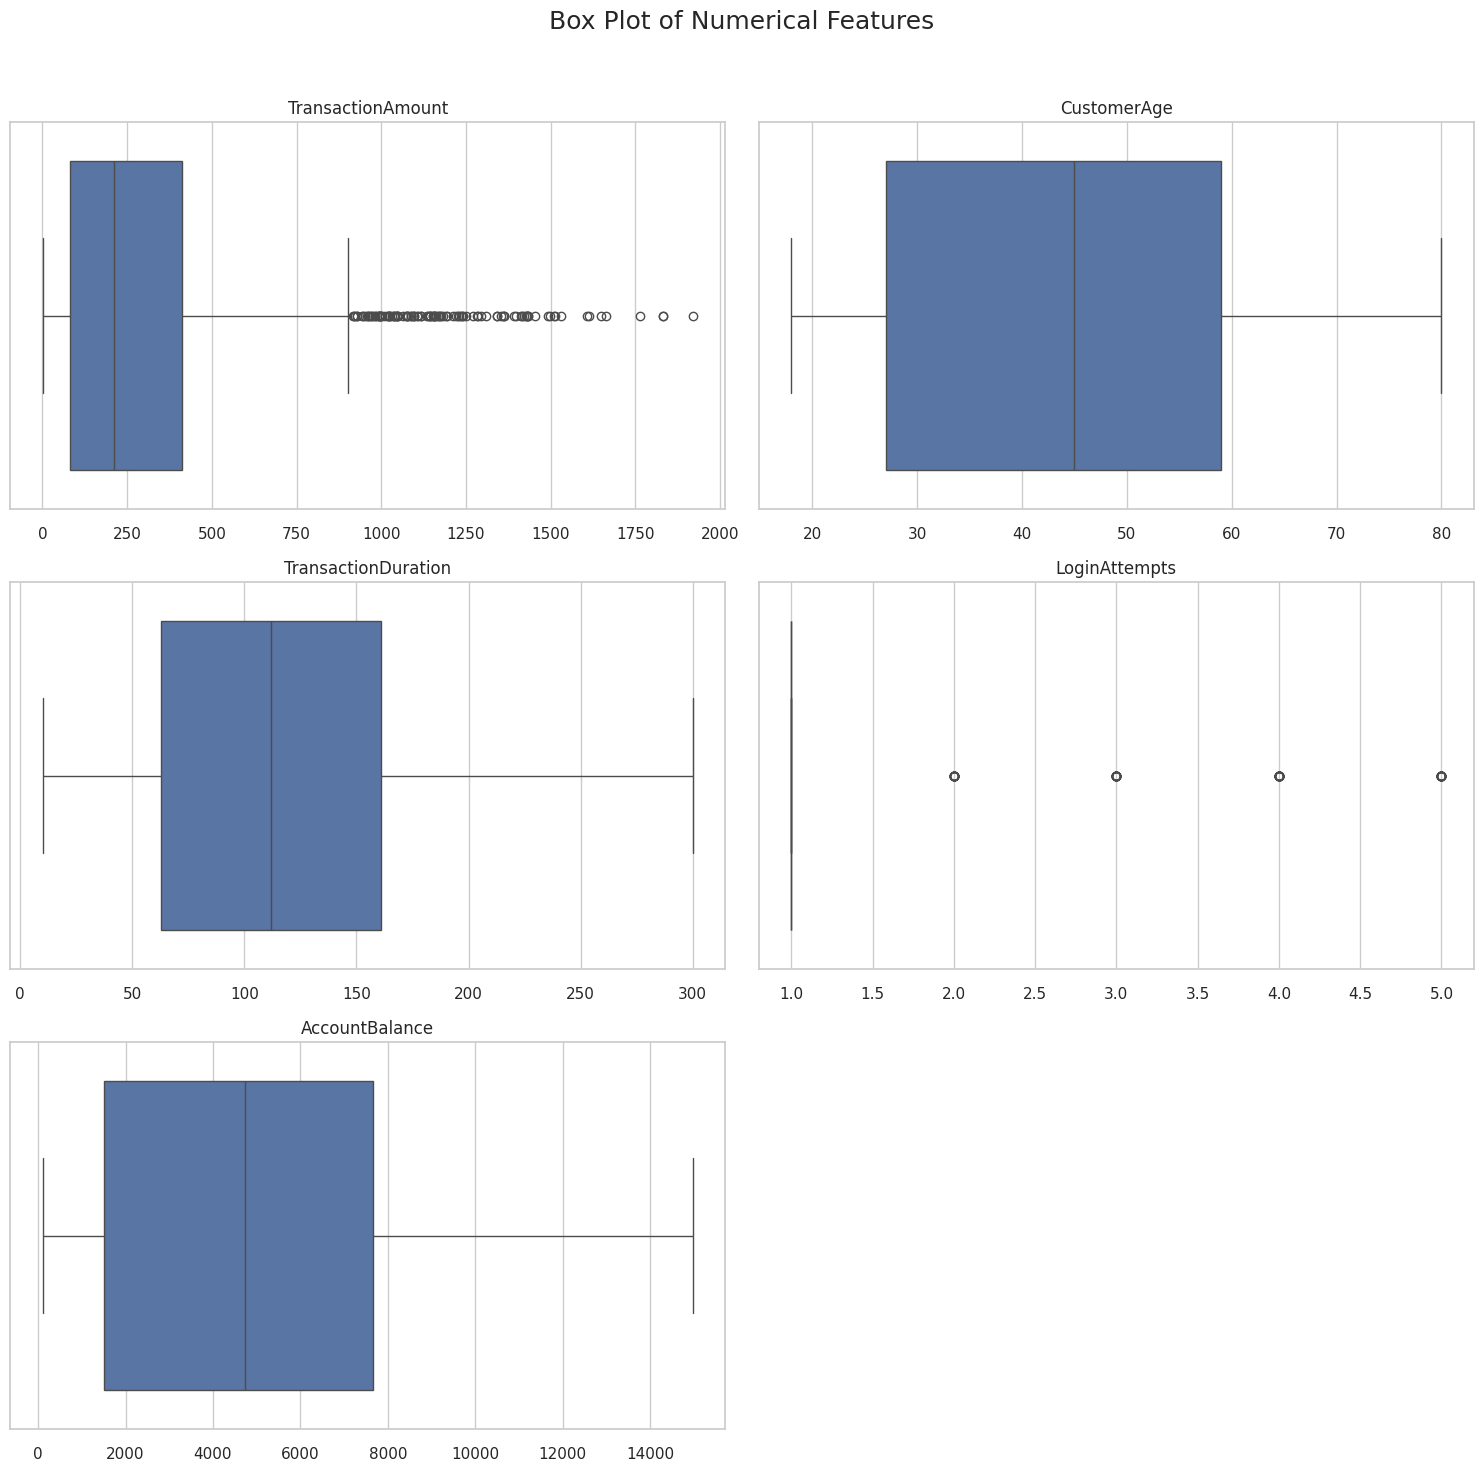

In [10]:
features_numericals = df.select_dtypes(include=np.number)

num_of_cols = len(features_numericals.columns)
plot_cols = 2
plot_rows = math.ceil(num_of_cols / plot_cols)

sns.set(style="whitegrid")
plt.figure(figsize=(15, 5 * plot_rows))
plt.suptitle('Box Plot of Numerical Features', fontsize=18, y=0.98)

for i, col in enumerate(features_numericals.columns, 1):
  plt.subplot(plot_rows, plot_cols, i)
  sns.boxplot(x=df[col])
  plt.title(col, fontsize=12)
  plt.xlabel('')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Applies the Interquartile Range (IQR) method to mathematically identify and calculate the exact percentage of outliers for each numerical feature.

In [11]:
for col in features_numericals:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  num_outliers = len(outliers)

  total_data = len(df)
  percentage = (num_outliers / total_data) * 100

  if num_outliers > 0:
    print(f"- {col}: {num_outliers} data ({percentage:.2f}%)")

- TransactionAmount: 113 data (4.45%)
- LoginAttempts: 120 data (4.73%)


## Correlation Between Numerical Features

Creates a correlation matrix and heatmap to identify linear relationships and potential multicollinearity between numerical variables.

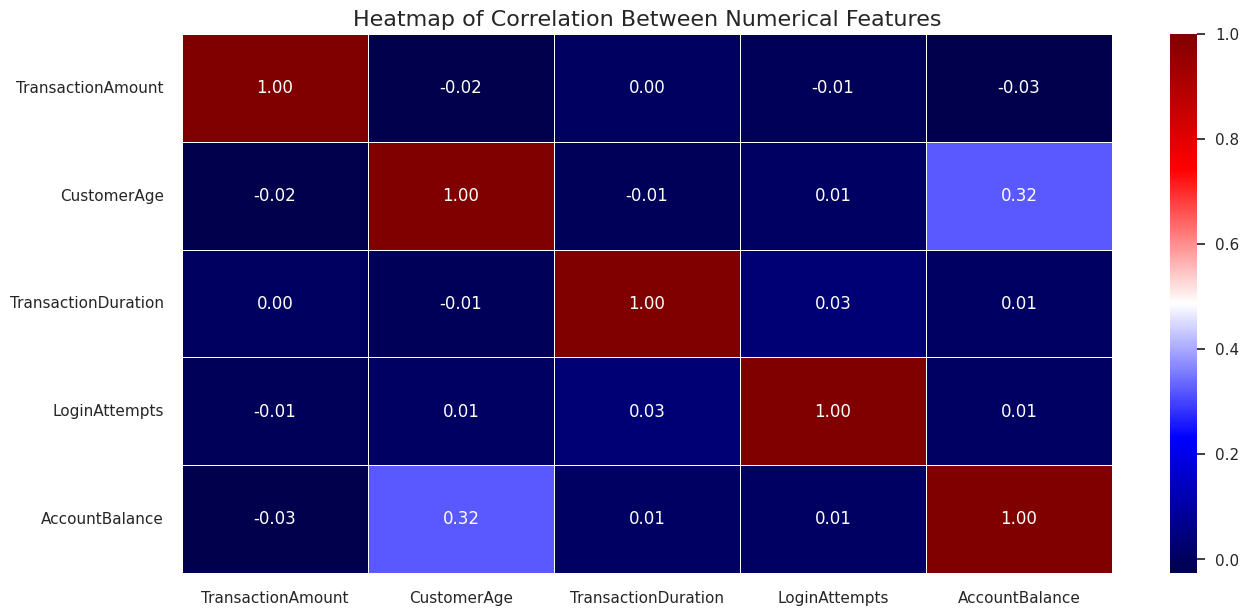

In [12]:
correalation_matrix = features_numericals.corr()

plt.figure(figsize=(15, 7))
sns.heatmap(correalation_matrix, annot=True, cmap='seismic', fmt='.2f', linewidths=.5)
plt.title('Heatmap of Correlation Between Numerical Features', fontsize=16)
plt.show()

## Distribution of Numerical Features

Renders interactive histograms using Plotly to analyze the distribution, spread, and skewness of all numerical features.

In [13]:
cols_to_plots = features_numericals.columns
num_features = len(cols_to_plots)
num_cols = 2
num_rows = math.ceil(num_features / num_cols)

fig = make_subplots(
  rows=num_rows,
  cols=num_cols,
  subplot_titles=cols_to_plots,
)

col_index = 0
for r in range(1, num_rows + 1):
  for c in range(1, num_cols + 1):
    if col_index < num_features:
      col_name = cols_to_plots[col_index]

      fig.add_trace(
        go.Histogram(
          x=features_numericals[col_name],
          name=col_name,
          marker=dict(
            color='light blue',
            line=dict(
              width=1
            )
          ),
          nbinsx=20
        ),
        row=r, col=c
      )
      col_index += 1

fig.update_layout(
  title_text="Distribution of Numerical Features",
  height=num_rows * 350,
  width=1300,
  showlegend=True,
  template='plotly_white'
)
fig.update_xaxes(type='linear', row=1, col=1)
fig.show()

## Comparing Data Distribution Between Data Categories

Uses box plots to compare how a specific numerical feature (e.g., Transaction Amount) is distributed across different categorical groups (e.g., Channel).

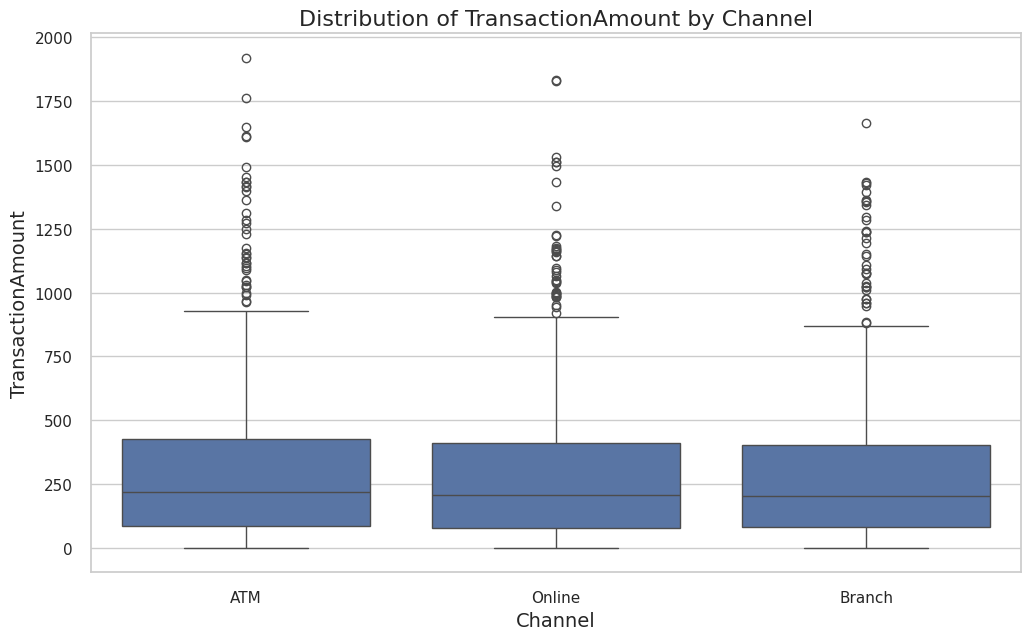

In [14]:
plt.figure(figsize=(12, 7))
sns.boxplot(x='Channel', y='TransactionAmount', data=df)
plt.title('Distribution of TransactionAmount by Channel', fontsize=16)
plt.xlabel('Channel', fontsize=14)
plt.ylabel('TransactionAmount', fontsize=14)
plt.show()

## Relationship Between Two Numerical Features

Utilizes scatter plots to explore potential correlations, patterns, and clustering tendencies between pairs of numerical features.

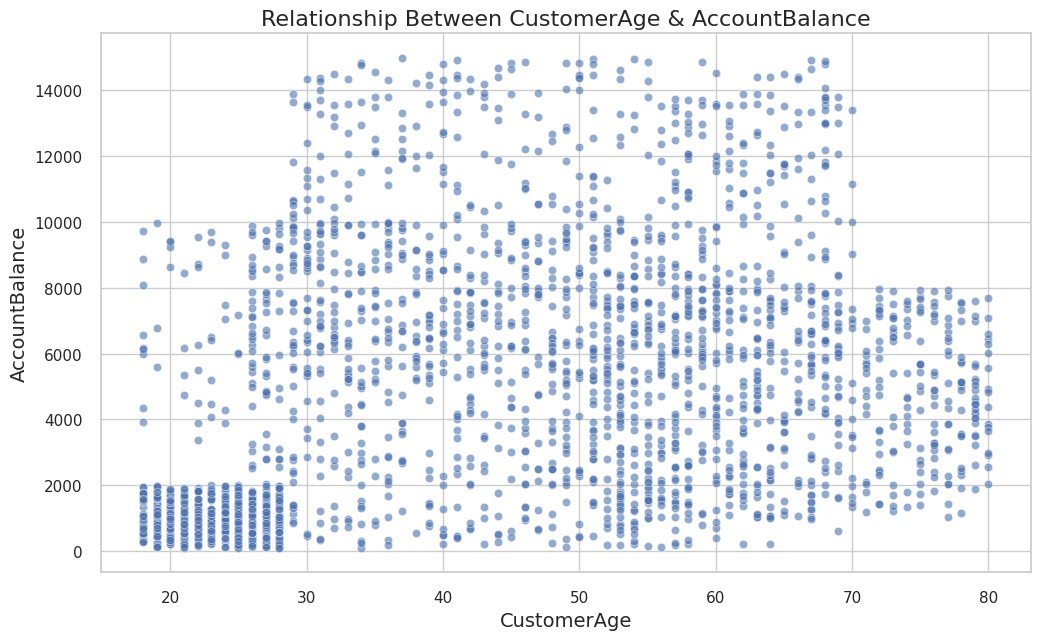

In [15]:
plt.figure(figsize=(12, 7))
sns.scatterplot(x='CustomerAge', y='AccountBalance', data=df, alpha=0.6)
plt.title('Relationship Between CustomerAge & AccountBalance', fontsize=16)
plt.xlabel('CustomerAge', fontsize=14)
plt.ylabel('AccountBalance', fontsize=14)
plt.show()

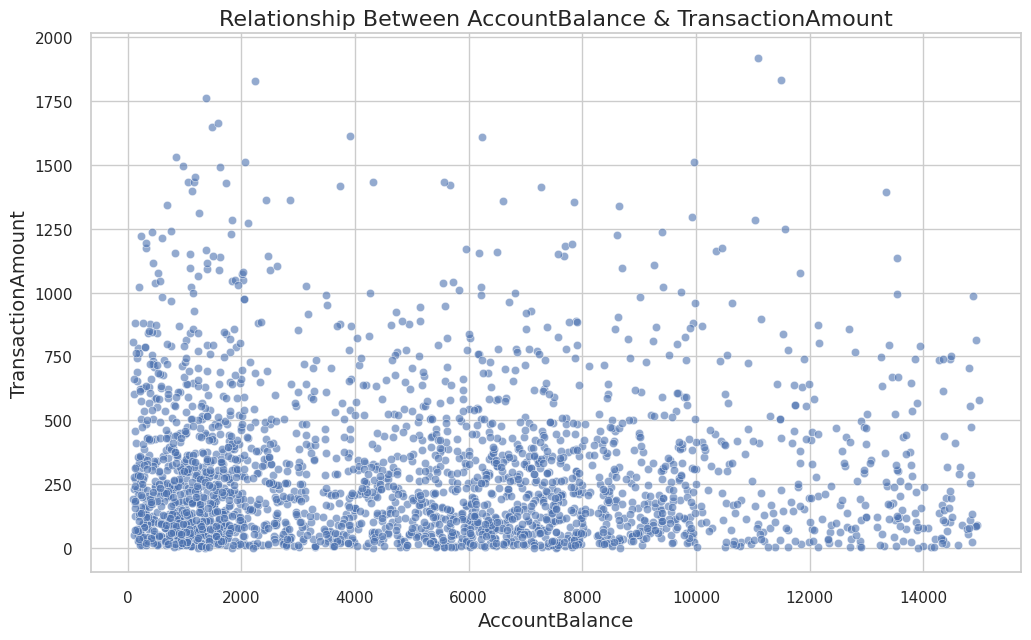

In [16]:
plt.figure(figsize=(12, 7))
sns.scatterplot(x='AccountBalance', y='TransactionAmount', data=df, alpha=0.6)
plt.title('Relationship Between AccountBalance & TransactionAmount', fontsize=16)
plt.xlabel('AccountBalance', fontsize=14)
plt.ylabel('TransactionAmount', fontsize=14)
plt.show()

## Counting the Number of Data in Each Category

Displays a sorted bar chart to show the frequency or count of transactions within a specific categorical feature.

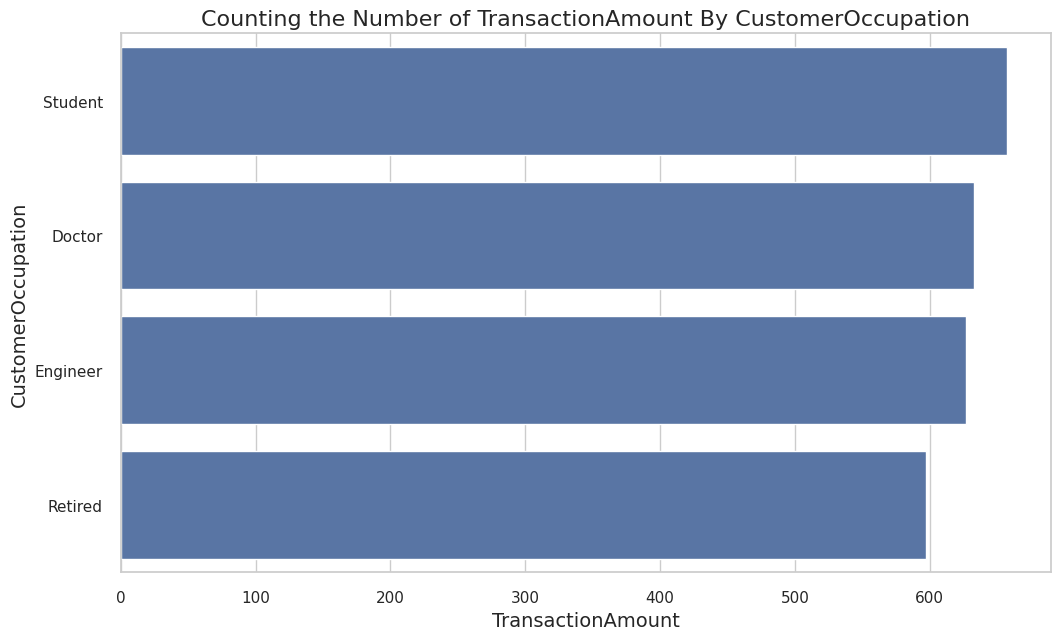

In [17]:
plt.figure(figsize=(12, 7))
sns.countplot(y='CustomerOccupation', data=df, order=df['CustomerOccupation'].value_counts().index)
plt.title('Counting the Number of TransactionAmount By CustomerOccupation', fontsize=16)
plt.xlabel('TransactionAmount', fontsize=14)
plt.ylabel('CustomerOccupation', fontsize=14)
plt.show()

# Data Cleaning and Preprocessing

Creates an independent copy of the original dataframe to preserve the raw data during the cleaning process.

In [18]:
df_cleaned = df.copy()

## Drop Duplicate Values

Identifies and drops identical rows to ensure data uniqueness and prevent model bias.

In [19]:
df_cleaned.drop_duplicates(inplace=True)

In [20]:
df_cleaned.duplicated().sum()

np.int64(0)

## Handling Missing Values

Handles missing values by forward-filling dates, dropping invalid records, and using median (for numerical) or mode (for categorical) imputation.

In [21]:
df_cleaned.fillna({ 'PreviousTransactionDate': df_cleaned['TransactionDate'] }, inplace=True)

In [22]:
df_cleaned.dropna(subset=['TransactionDate'], inplace=True)

In [23]:
for col in ['TransactionAmount', 'CustomerAge', 'TransactionDuration', 'LoginAttempts', 'AccountBalance']:
  median_value = df_cleaned[col].median()
  df_cleaned.fillna({ col: median_value }, inplace=True)

In [24]:
for col in ['Location', 'Channel', 'CustomerOccupation', 'TransactionType']:
  mode_value = df_cleaned[col].mode()[0]
  df_cleaned.fillna({ col: mode_value }, inplace=True)

In [25]:
df_cleaned.isnull().sum()

,0
TransactionID,29
AccountID,20
TransactionAmount,0
TransactionDate,0
TransactionType,0
Location,0
DeviceID,30
IP Address,20
MerchantID,23
Channel,0


## Feature Engineering

Transforms raw temporal data to calculate the time elapsed since the last transaction and generates a composite risk score feature based on login attempts and transaction amounts.

In [26]:
df_cleaned['TransactionDate'] = pd.to_datetime(df_cleaned['TransactionDate'])
df_cleaned['PreviousTransactionDate'] = pd.to_datetime(df_cleaned['PreviousTransactionDate'])

df_cleaned['TimeSinceLastTransaction'] = (df_cleaned['TransactionDate'] - df_cleaned['PreviousTransactionDate']).dt.total_seconds()
df_cleaned['TimeSinceLastTransaction'].fillna(df_cleaned['TimeSinceLastTransaction'].median(), inplace=True)

In [27]:
df_cleaned['RiskScoreLoginAmount'] = (np.log1p(df_cleaned['LoginAttempts'])) * (np.log1p(df_cleaned['TransactionAmount']))

## Remove Irrelevant Features

Removes non-predictive unique identifiers and redundant date columns to reduce dimensionality and noise.

In [28]:
df_cleaned.drop(['TransactionID', 'AccountID', 'DeviceID', 'IP Address', 'MerchantID'], axis=1, inplace=True)

In [29]:
df_cleaned.drop(['TransactionDate'], axis=1, inplace=True)
df_cleaned.drop(['PreviousTransactionDate'], axis=1, inplace=True)

## Handling Outliers

Calculates the Interquartile Range (IQR) to detect extreme outliers in transaction amounts and caps them at the established upper and lower boundaries.

In [30]:
Q1 = df_cleaned['TransactionAmount'].quantile(0.25)
Q3 = df_cleaned['TransactionAmount'].quantile(0.75)

IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_cleaned['TransactionAmount'] = np.where(df_cleaned['TransactionAmount'] < lower_bound, lower_bound, df_cleaned['TransactionAmount'])
df_cleaned['TransactionAmount'] = np.where(df_cleaned['TransactionAmount'] > upper_bound, upper_bound, df_cleaned['TransactionAmount'])

## Binning Data

Converts continuous numerical variables (Customer Age and Transaction Amount) into discrete categorical bins to capture non-linear patterns.

In [31]:
customerAge_bins = [0, 29, 59, 150]
customerAge_labels = ['Young', 'Adult', 'Older']
df_cleaned['CustomerAgeCategory'] = pd.cut(df_cleaned['CustomerAge'], bins=customerAge_bins, labels=customerAge_labels, right=True)

In [32]:
transactionAmount_bins = [0, 250, 1000, 5000, float('inf')]
transactionAmount_labels = ['Low', 'Medium', 'High', 'Very High']
df_cleaned['TransactionAmountCategory'] = pd.cut(df_cleaned['TransactionAmount'], bins=transactionAmount_bins, labels=transactionAmount_labels, right=True)

## LabelEncoder

Applies Label Encoding to transform text-based categories and binned groups into machine-readable numerical formats, storing the encoders for future deployment.

In [33]:
df_encoded = df_cleaned.copy()
encoders = {}

In [34]:
le_age = LabelEncoder()
df_encoded['CustomerAgeCategoryEncoded'] = le_age.fit_transform(df_encoded['CustomerAgeCategory'])
encoders['CustomerAgeCategoryEncoded'] = le_age

In [35]:
le_amount = LabelEncoder()
df_encoded['TransactionAmountCategoryEncoded'] = le_amount.fit_transform(df_encoded['TransactionAmountCategory'])
encoders['TransactionAmountCategoryEncoded'] = le_amount

In [36]:
df_encoded.drop(['CustomerAgeCategory', 'TransactionAmountCategory'], axis=1, inplace=True)

In [37]:
features_categoricals = df_encoded.select_dtypes(include='object').columns
for col in features_categoricals:
  le = LabelEncoder()
  df_encoded[col] = le.fit_transform(df_encoded[col])
  encoders[col] = le

## StandardScaler

Standardizes numerical features by removing the mean and scaling to unit variance, ensuring all variables are on the same scale for the machine learning algorithms.

In [38]:
features_numericals_cols = [
  'TransactionAmount',
  'CustomerAge',
  'TransactionDuration',
  'LoginAttempts',
  'AccountBalance',
]
scaler = StandardScaler()
df_encoded[features_numericals_cols] = scaler.fit_transform(df_encoded[features_numericals_cols])

# Model Clustering

## Finalizing Data for Modeling

Creates a final, independent copy of the fully encoded and scaled dataset to be fed into the clustering algorithms.

In [39]:
df_final = df_encoded.copy()
df_final.head()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TimeSinceLastTransaction,RiskScoreLoginAmount,CustomerAgeCategoryEncoded,TransactionAmountCategoryEncoded
0,-1.076659,1,36,0,1.429797,0,-0.553503,-0.205826,-0.003205,-49477134.0,1.881224,1,0
1,0.374644,1,15,0,1.317091,0,0.306585,-0.205826,2.226999,-42823516.0,4.112360,1,1
2,-0.627022,1,23,2,-1.444202,3,-0.911873,-0.205826,-1.032291,-41694656.0,3.359316,2,0
3,-0.393747,1,33,2,-1.049732,3,-1.356251,-0.205826,0.888405,-47403415.0,3.620346,2,0
4,-1.079224,0,1,2,0.020974,3,1.123668,-0.205826,0.594457,-33228915.0,1.851184,0,0


## Determining Optimal Clusters (Elbow Method)

Utilizes the Yellowbrick KElbowVisualizer to programmatically find the optimal number of clusters (k) by plotting the distortion score and identifying the elbow point.

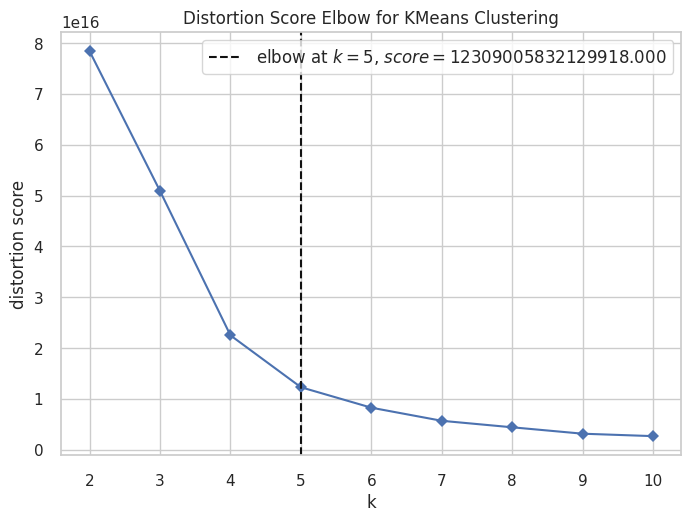

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [40]:
model = KMeans(random_state=42, n_init='auto')
visualizer = KElbowVisualizer(
  model,
  k=(2, 11),
  timings=False,
  locate_elbow=True
)
visualizer.fit(df_final)
n_cluster = visualizer.elbow_value_
visualizer.show()

## K-Means Model Training

Instantiates and trains the Base K-Means clustering model using the optimal number of clusters discovered in the previous step. Extracts cluster labels and centroid coordinates.

In [41]:
kmeans = KMeans(n_clusters=n_cluster, n_init='auto', random_state=42)
cluster_labels = kmeans.fit_predict(df_final)
centroids = kmeans.cluster_centers_

## Base Model Evaluation (Silhouette Score)

Calculates the Silhouette Score to evaluate the quality and cohesion of the formed clusters. A score closer to 1 indicates well-separated and distinct clusters.

In [42]:
silhouette_score_kmeans = silhouette_score(df_final, cluster_labels)
silhouette_score_kmeans

np.float64(0.5892880559787999)

## Appending Cluster Labels

Attaches the generated cluster labels back to the main dataframe for profiling and analysis purposes.

In [43]:
df_cluster = df_final.copy()
df_cluster['Cluster'] = cluster_labels

## Visualizing Base Clusters and Centroids

Generates a 2D scatter plot to visualize the distribution of the clusters alongside their respective centroids, mapped across two primary financial features.

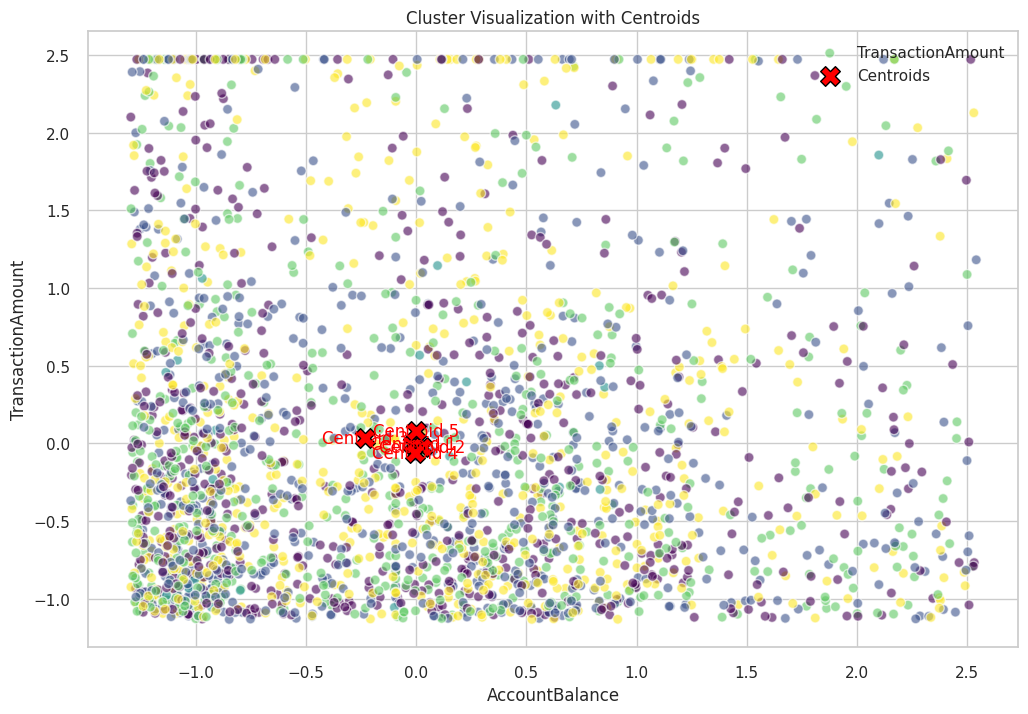

In [44]:
plt.figure(figsize=(12, 8))
plt.scatter(data=df_cluster, x='AccountBalance', y='TransactionAmount', c=cluster_labels, cmap='viridis', s=50, alpha=0.6, edgecolors='w', marker='o')

col_idx_x = df_final.columns.get_loc('AccountBalance')
col_idx_y = df_final.columns.get_loc('TransactionAmount')

plt.scatter(centroids[:, col_idx_x], centroids[:, col_idx_y], c='red', s=200, marker='X', label='Centroids', edgecolors='black')

for i, centroid in enumerate(centroids):
  plt.text(centroid[col_idx_x], centroid[col_idx_y], f'Centroid {i+1}', color='red', fontsize=12, ha='center', va='center')

plt.title('Cluster Visualization with Centroids')
plt.xlabel('AccountBalance')
plt.ylabel('TransactionAmount')
plt.legend()
plt.show()

## Exporting Base Model

Saves the trained K-Means model to a local directory using joblib for future deployment and inference.

In [45]:
if not os.path.exists('models'):
  os.makedirs('models')

joblib.dump(kmeans, 'models/clustering_kmeans.h5')

['models/clustering_kmeans.h5']

## Dimensionality Reduction (PCA) & Clustering

Applies Principal Component Analysis (PCA) to reduce the dataset's dimensionality while retaining the most variance. Retrains a new K-Means model on the principal components to handle potential high-dimensionality noise.

In [46]:
n_components_pca = 5
pca = PCA(n_components=n_components_pca, random_state=42)

principal_components = pca.fit_transform(df_final)

df_kmeans_pca = pd.DataFrame(data=principal_components, columns=[f'PCA{i+1}' for i in range(n_components_pca)])
df_kmeans_pca.columns = df_kmeans_pca.columns.astype(str)

kmeans_pca = KMeans(n_clusters=n_cluster, n_init='auto', random_state=42)
kmeans_pca.fit(df_kmeans_pca)
centroids_pca = kmeans_pca.cluster_centers_
cluster_labels_pca = kmeans_pca.labels_

## PCA Model Evaluation

Calculates the Silhouette Score for the PCA-optimized K-Means model to compare its performance and cluster density against the base model.

In [47]:
silhouette_score_kmeans_pca = silhouette_score(df_kmeans_pca, cluster_labels_pca)
silhouette_score_kmeans_pca

np.float64(0.589288056107001)

## Appending PCA Cluster Labels

Adds the new cluster labels generated by the PCA-integrated model to the dataset for final comparison.

In [48]:
df_cluster['ClusterPCA'] = cluster_labels_pca

## Visualizing PCA Clusters

Renders a scatter plot using the PCA-generated cluster labels to visually inspect any improvements in cluster separation and boundary definitions.

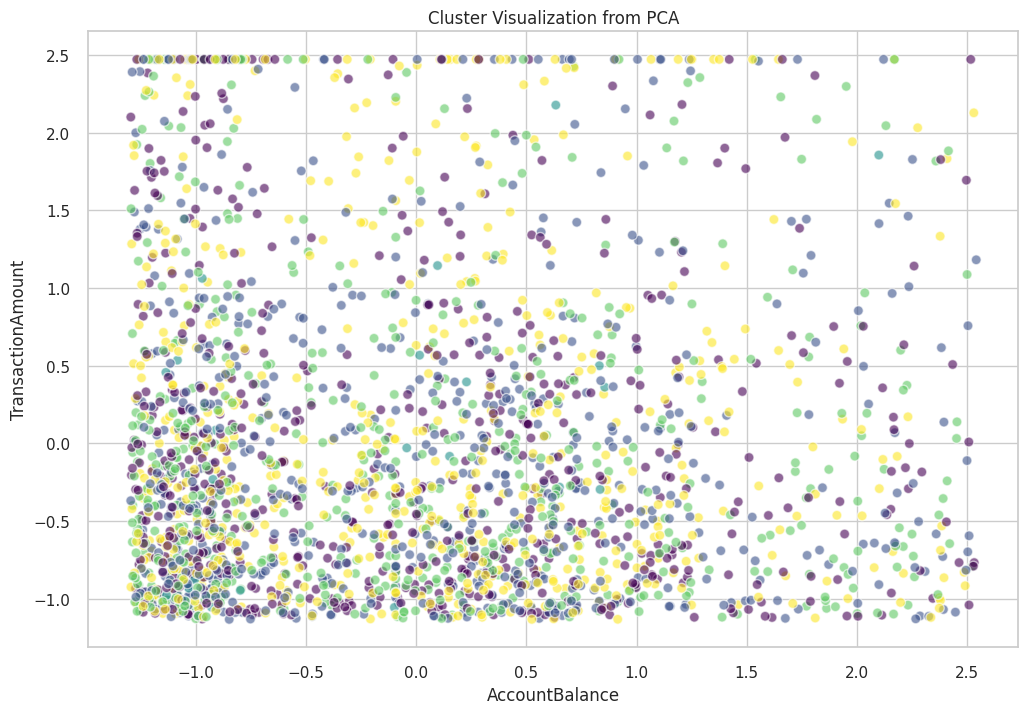

In [49]:
plt.figure(figsize=(12, 8))
plt.scatter(data=df_cluster, x='AccountBalance', y='TransactionAmount', c=cluster_labels_pca, cmap='viridis', s=50, alpha=0.6, edgecolors='w', marker='o')
plt.title('Cluster Visualization from PCA')
plt.xlabel('AccountBalance')
plt.ylabel('TransactionAmount')
plt.show()

## Exporting PCA-Optimized Model

Saves the final PCA-integrated K-Means model, which is typically more robust for production environments, to local storage.

In [50]:
if not os.path.exists('models'):
  os.makedirs('models')

joblib.dump(kmeans_pca, 'models/clustering_kmeans_pca.h5')

['models/clustering_kmeans_pca.h5']

# Cluster Interpretation

Previews the dataset to verify that the newly generated cluster labels have been successfully appended to the records before analysis.

In [51]:
df_cluster.head()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TimeSinceLastTransaction,RiskScoreLoginAmount,CustomerAgeCategoryEncoded,TransactionAmountCategoryEncoded,Cluster,ClusterPCA
0,-1.076659,1,36,0,1.429797,0,-0.553503,-0.205826,-0.003205,-49477134.0,1.881224,1,0,3,3
1,0.374644,1,15,0,1.317091,0,0.306585,-0.205826,2.226999,-42823516.0,4.112360,1,1,3,3
2,-0.627022,1,23,2,-1.444202,3,-0.911873,-0.205826,-1.032291,-41694656.0,3.359316,2,0,4,4
3,-0.393747,1,33,2,-1.049732,3,-1.356251,-0.205826,0.888405,-47403415.0,3.620346,2,0,3,3
4,-1.079224,0,1,2,0.020974,3,1.123668,-0.205826,0.594457,-33228915.0,1.851184,0,0,1,1


Aggregates the dataset by cluster to compute core descriptive statistics (mean, minimum, maximum) for key numerical features. Applies custom styling and formatting to the output table to easily interpret, compare, and define the unique characteristics (persona) of each customer segment or anomaly group.

In [52]:
df_analysis = df_cluster.copy()
df_analysis['Cluster'] = cluster_labels

numerical_features_for_analysis = [
  'TransactionAmount',
  'CustomerAge',
  'TransactionDuration',
  'LoginAttempts',
  'AccountBalance',
  'TimeSinceLastTransaction',
  'RiskScoreLoginAmount',
]
cluster_analysis = df_analysis.groupby('Cluster')[numerical_features_for_analysis].agg(
  ['mean', 'min', 'max']
)

styled_analysis = cluster_analysis.style.format({
  ('TransactionAmount', 'mean'): '${:,.2f}',
  ('TransactionAmount', 'min'): '${:,.2f}',
  ('TransactionAmount', 'max'): '${:,.2f}',
  ('CustomerAge', 'mean'): '{:.1f}',
  ('CustomerAge', 'min'): '{:.1f}',
  ('CustomerAge', 'max'): '{:.1f}',
  ('CustomerAge', 'max'): '{:.1f}',
  ('AccountBalance', 'mean'): '${:,.2f}',
  ('AccountBalance', 'min'): '${:,.2f}',
  ('AccountBalance', 'max'): '${:,.2f}',
}).set_caption("Descriptive Analysis Table per Cluster") \
  .set_table_styles([
    {'selector': 'th:nth-child(2), td:nth-child(2)',
     'props': [('border-left', '2px solid #ccc')]},

    {'selector': 'th:nth-child(5), td:nth-child(5)',
     'props': [('border-left', '2px solid #ccc')]},

    {'selector': 'th:nth-child(8), td:nth-child(8)',
     'props': [('border-left', '2px solid #ccc')]},

    {'selector': 'th:nth-child(11), td:nth-child(11)',
     'props': [('border-left', '2px solid #ccc')]},

    {'selector': 'th:nth-child(14), td:nth-child(14)',
     'props': [('border-left', '2px solid #ccc')]},

    {'selector': 'th:nth-child(17), td:nth-child(17)',
     'props': [('border-left', '2px solid #ccc')]},

    {'selector': 'th:nth-child(20), td:nth-child(20)',
     'props': [('border-left', '2px solid #ccc')]},
], overwrite=False)
styled_analysis

**Cluster Interpretation: Defining Customer Personas**

Based on the statistical aggregation of the numerical features, we have identified 5 distinct segments within the bank transaction data:

- Cluster 0: Erratic High-Frequency Users (Potential Security Risk)
    - Mean Transaction Amount: -0.00
    - Mean Customer Age: -0.1
    - Analysis: This group consists of slightly younger customers with average transaction amounts but exhibits irregular login patterns (high max login attempts) and extremely negative time intervals. This cluster might represent system-driven anomalies or users experiencing technical friction. The recommendation is to trigger enhanced MFA (Multi-Factor Authentication) for this group to ensure account security.

- Cluster 1: The Stable Mainstream Segment (Low Risk)
    - Mean Transaction Amount: -0.02
    - Mean Customer Age: 0.0
    - Analysis: This is the most balanced cluster, representing the average bank customer. Their behavior is predictable, with neutral age and transaction values. They represent the core stable user base with very low risk. Marketing should focus on retention through loyalty programs or standard personal loan offers.

- Cluster 2: High-Velocity Instant Transactors (High-Alert Group)
    - Mean Transaction Amount: 0.03
    - Mean Customer Age: -0.6
    - Analysis: This is the youngest demographic with the highest velocity; their `TimeSinceLastTransaction` mean is exactly 0.0, suggesting simultaneous or back-to-back transactions. Combined with a higher-than-average `RiskScoreLoginAmount`, this cluster likely represents Velocity Attacks or bot-like behavior. Immediate real-time monitoring and transaction limits are recommended for this specific group.

- Cluster 3: Cautious Low-Value Customers
    - Mean Transaction Amount: -0.06
    - Mean Customer Age: 0.0
    - Analysis: These customers perform the lowest-value transactions in the dataset. They tend to have longer gaps between activities and conservative spending habits. The recommendation for this group is to offer micro-savings products or low-cost banking features to encourage more frequent engagement without overwhelming their financial capacity.

- Cluster 4: The High-Value Premium Segment
    - Mean Transaction Amount: 0.08
    - Mean Customer Age: 0.0
    - Analysis: This cluster holds the highest mean transaction amount and strong account balances. They are the Whales of the platform, contributing the most to the bank's transaction volume. The focus should be on premium services, such as dedicated wealth management, higher credit limits, and exclusive investment opportunities.

# Inverse Transform

Creates an independent copy of the clustered dataset to safely perform inverse transformations without altering the original modeling data.

In [53]:
df_inverse = df_cluster.copy()

Standardizes the dataframe by renaming the target column to explicitly represent the assigned cluster labels.

In [54]:
df_inverse.rename(columns={'Target': 'Cluster'}, inplace=True)

Reverses the StandardScaler transformation to restore numerical features to their original, real-world metrics (e.g., actual dollar amounts and exact duration).

In [55]:
df_inverse[features_numericals_cols] = scaler.inverse_transform(df_cluster[features_numericals_cols])

display(df_inverse.head())

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TimeSinceLastTransaction,RiskScoreLoginAmount,CustomerAgeCategoryEncoded,TransactionAmountCategoryEncoded,Cluster,ClusterPCA
0,14.09,1,36,0,70.0,0,81.0,1.0,5112.21,-49477134.0,1.881224,1,0,3,3
1,376.24,1,15,0,68.0,0,141.0,1.0,13758.91,-42823516.0,4.112360,1,1,3,3
2,126.29,1,23,2,19.0,3,56.0,1.0,1122.35,-41694656.0,3.359316,2,0,4,4
3,184.50,1,33,2,26.0,3,25.0,1.0,8569.06,-47403415.0,3.620346,2,0,3,3
4,13.45,0,1,2,45.0,3,198.0,1.0,7429.40,-33228915.0,1.851184,0,0,1,1


Reverses the LabelEncoder transformation to convert the encoded numeric classes back into their original, human-readable text categories.

In [56]:
features_categoricals_to_inverse = list(features_categoricals) + ['CustomerAgeCategoryEncoded', 'TransactionAmountCategoryEncoded']
for col in features_categoricals_to_inverse:
  le = encoders[col]
  df_inverse[col] = le.inverse_transform(df_cluster[col])

display(df_inverse.head())

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TimeSinceLastTransaction,RiskScoreLoginAmount,CustomerAgeCategoryEncoded,TransactionAmountCategoryEncoded,Cluster,ClusterPCA
0,14.09,Debit,San Diego,ATM,70.0,Doctor,81.0,1.0,5112.21,-49477134.0,1.881224,Older,Low,3,3
1,376.24,Debit,Houston,ATM,68.0,Doctor,141.0,1.0,13758.91,-42823516.0,4.112360,Older,Medium,3,3
2,126.29,Debit,Mesa,Online,19.0,Student,56.0,1.0,1122.35,-41694656.0,3.359316,Young,Low,4,4
3,184.50,Debit,Raleigh,Online,26.0,Student,25.0,1.0,8569.06,-47403415.0,3.620346,Young,Low,3,3
4,13.45,Credit,Atlanta,Online,45.0,Student,198.0,1.0,7429.40,-33228915.0,1.851184,Adult,Low,1,1


Generates a styled statistical summary table grouped by cluster using the newly restored original values. This provides a clear, business-friendly interpretation of each cluster's persona.

In [57]:
df_analysis_inverse = df_inverse.copy()
df_analysis_inverse['Cluster'] = cluster_labels

numerical_features_for_analysis = [
  'TransactionAmount',
  'CustomerAge',
  'TransactionDuration',
  'LoginAttempts',
  'AccountBalance',
  'TimeSinceLastTransaction',
  'RiskScoreLoginAmount',
]
cluster_analysis = df_analysis_inverse.groupby('Cluster')[numerical_features_for_analysis].agg(
  ['mean', 'min', 'max']
)

styled_analysis = cluster_analysis.style.format({
  ('TransactionAmount', 'mean'): '${:,.2f}',
  ('TransactionAmount', 'min'): '${:,.2f}',
  ('TransactionAmount', 'max'): '${:,.2f}',
  ('CustomerAge', 'mean'): '{:.1f}',
  ('CustomerAge', 'min'): '{:.1f}',
  ('CustomerAge', 'max'): '{:.1f}',
  ('CustomerAge', 'max'): '{:.1f}',
  ('AccountBalance', 'mean'): '${:,.2f}',
  ('AccountBalance', 'min'): '${:,.2f}',
  ('AccountBalance', 'max'): '${:,.2f}',
}).set_caption("Descriptive Analysis Table per Cluster") \
  .set_table_styles([
    {'selector': 'th:nth-child(2), td:nth-child(2)',
     'props': [('border-left', '2px solid #ccc')]},

    {'selector': 'th:nth-child(5), td:nth-child(5)',
     'props': [('border-left', '2px solid #ccc')]},

    {'selector': 'th:nth-child(8), td:nth-child(8)',
     'props': [('border-left', '2px solid #ccc')]},

    {'selector': 'th:nth-child(11), td:nth-child(11)',
     'props': [('border-left', '2px solid #ccc')]},

    {'selector': 'th:nth-child(14), td:nth-child(14)',
     'props': [('border-left', '2px solid #ccc')]},

    {'selector': 'th:nth-child(17), td:nth-child(17)',
     'props': [('border-left', '2px solid #ccc')]},

    {'selector': 'th:nth-child(20), td:nth-child(20)',
     'props': [('border-left', '2px solid #ccc')]},

    {'selector': 'th:nth-child(23), td:nth-child(23)',
     'props': [('border-left', '2px solid #ccc')]},

], overwrite=False)
styled_analysis

**Cluster Interpretation: Defining Customer Personas (Actual Values)**

Based on the real-world values restored through the inverse transformation process, we can clearly define the characteristics and behavioral patterns of each segment:

- Cluster 0: Infrequent Mature Transactors
    - Mean Transaction Amount: 282.38
    - Mean Customer Age: 43.6 years
    - Analysis: This cluster consists of middle-aged customers who perform moderate-to-high value transactions. The extremely large negative value in `TimeSinceLastTransaction` suggests these are either first-time transactions or users with very long gaps between activities. They are generally stable but infrequent users. Recommendations include engagement campaigns to increase transaction frequency.

- Cluster 1: Established Adult Segment
    - Mean Transaction Amount: 277.71
    - Mean Customer Age: 44.9 years
    - Analysis: This is the oldest demographic in the dataset. They maintain the highest average account balance (~$5,230) and show very steady, conservative behavior. This group represents the Loyal base. They are low-risk customers, ideal for long-term investment products or retirement planning services.

- Cluster 2: High-Risk Velocity Anomalies (Urgent Alert)
    - Mean Transaction Amount: 291.21
    - Mean Customer Age: 34.5 years
    - Analysis: This is the most critical group for fraud detection. It is the youngest group, and most importantly, the `TimeSinceLastTransaction` is exactly 0.0. This indicates Velocity Attacks where multiple transactions occur at the exact same second. Combined with the highest `RiskScoreLoginAmount` (3.87), this cluster is flagged as High Risk/Fraudulent. Immediate account freezing or manual review is required for transactions in this cluster.

- Cluster 3: Conservative Low-Value Spenders
    - Mean Transaction Amount: 267.09
    - Mean Customer Age: 45.3 years
    - Analysis: This cluster contains the oldest customers with the lowest average transaction amounts. Their behavior is very cautious and safe. Like Cluster 0 and 1, they show irregular patterns in transaction timing but their small transaction sizes make them a very low priority for fraud investigation. They are best suited for basic savings or micro-insurance products.

- Cluster 4: High-Value Premium Transactors
    - Mean Transaction Amount: 302.75
    - Mean Customer Age: 45.2 years
    - Analysis: This group represents the Premium segment. They have the highest mean transaction amount exceeding $300. Despite their high spending, their login attempts and risk scores remain low, indicating legitimate high-value activity. The bank should prioritize this group for premium credit card offers, priority banking, and higher transaction limits.

Renders 100% stacked bar charts using cross-tabulation to visualize the proportional distribution of the original categorical features within each cluster.

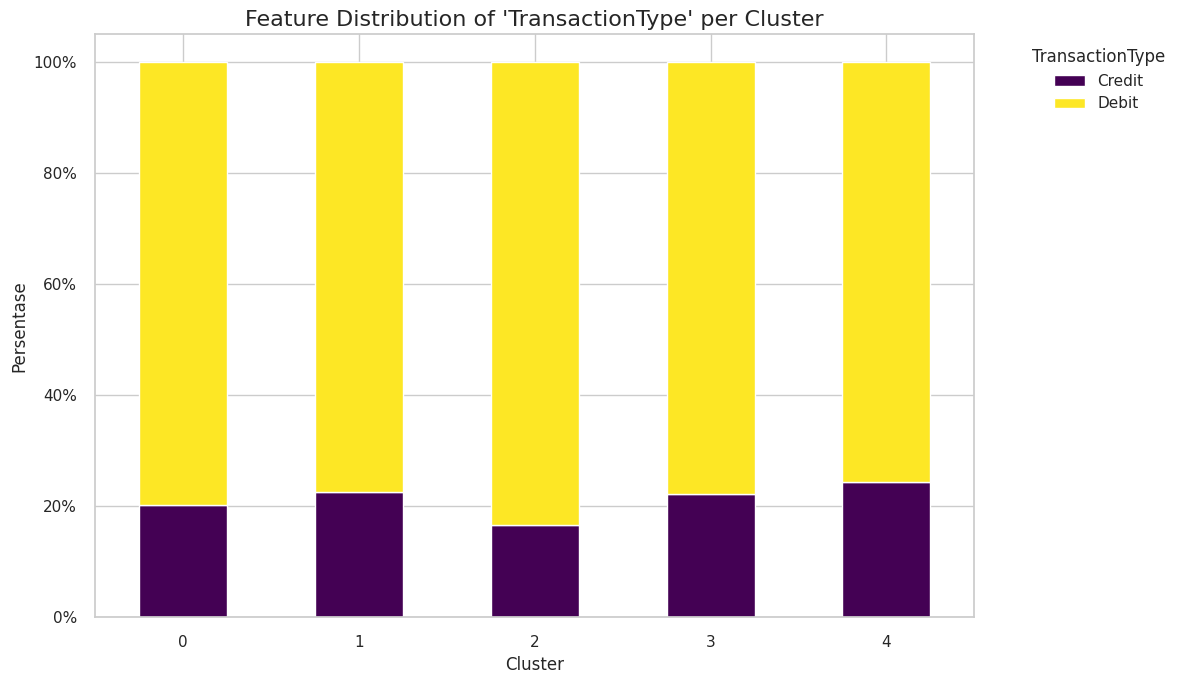

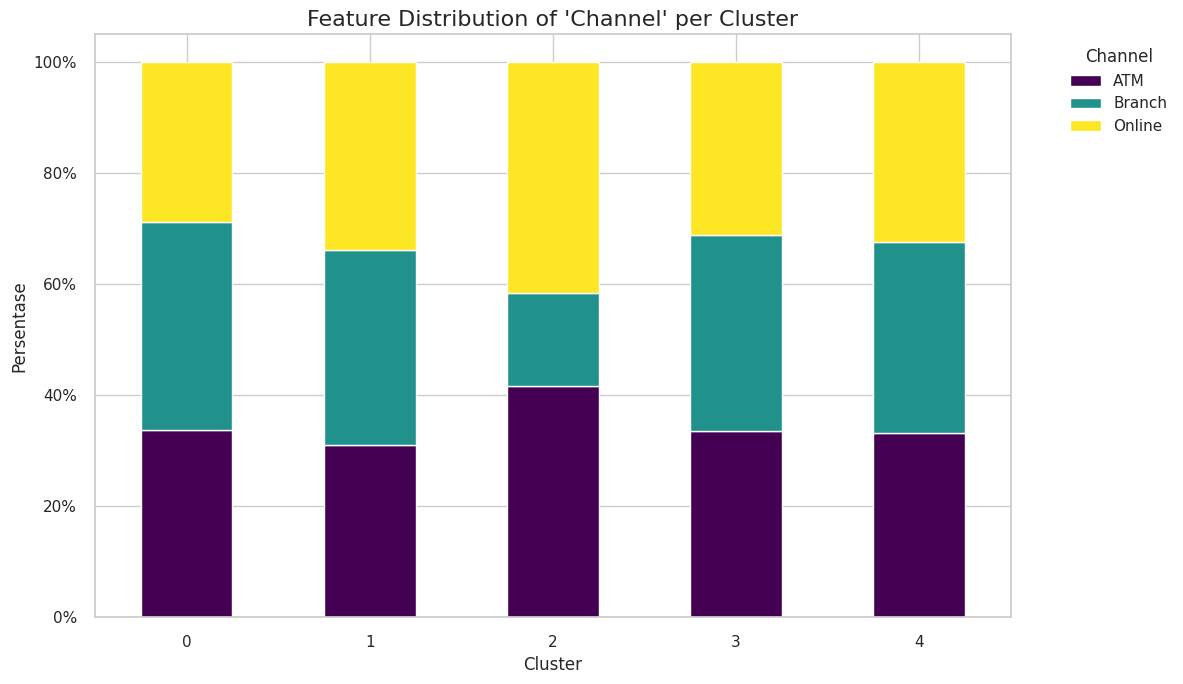

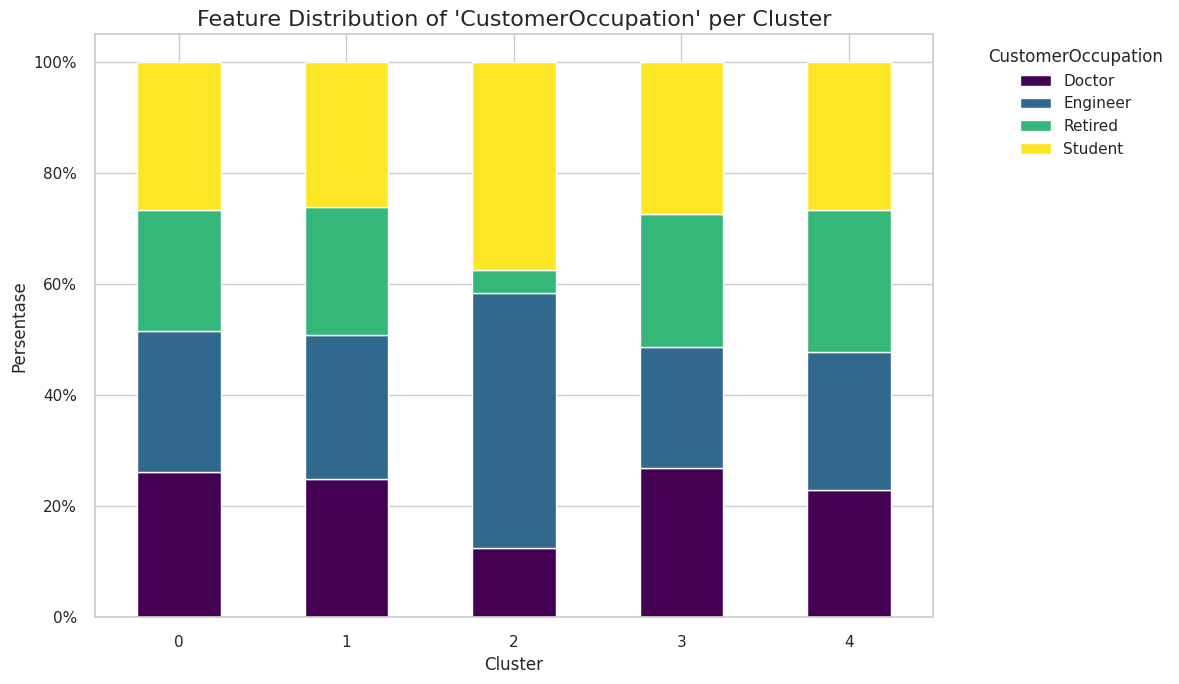

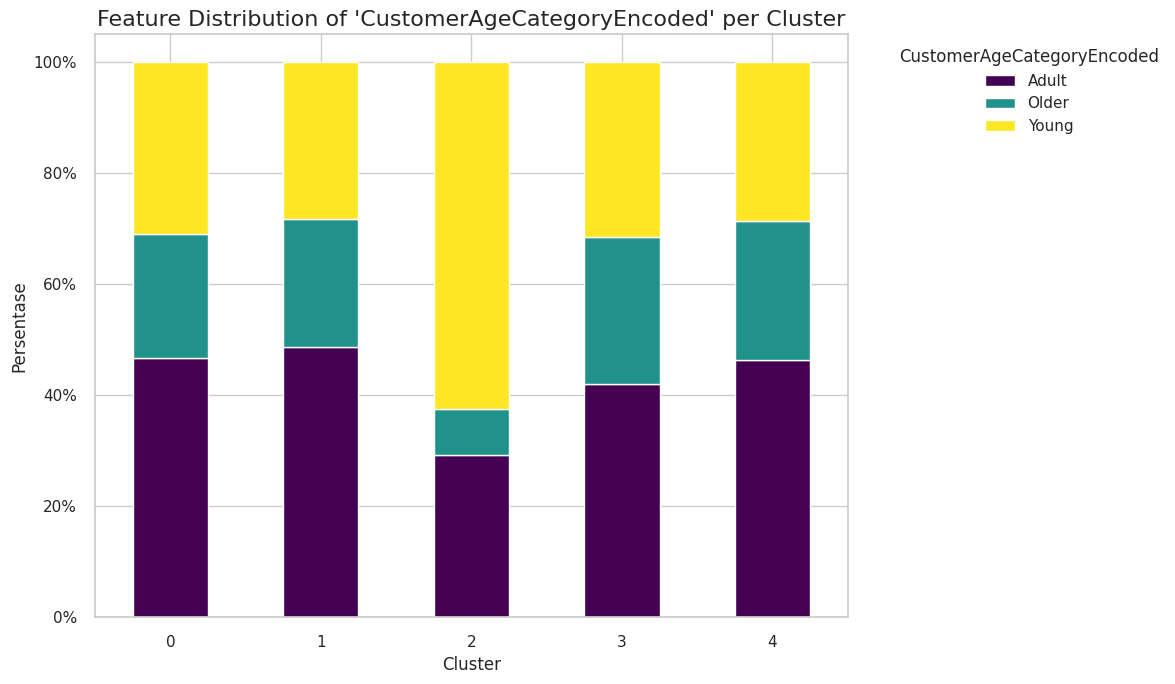

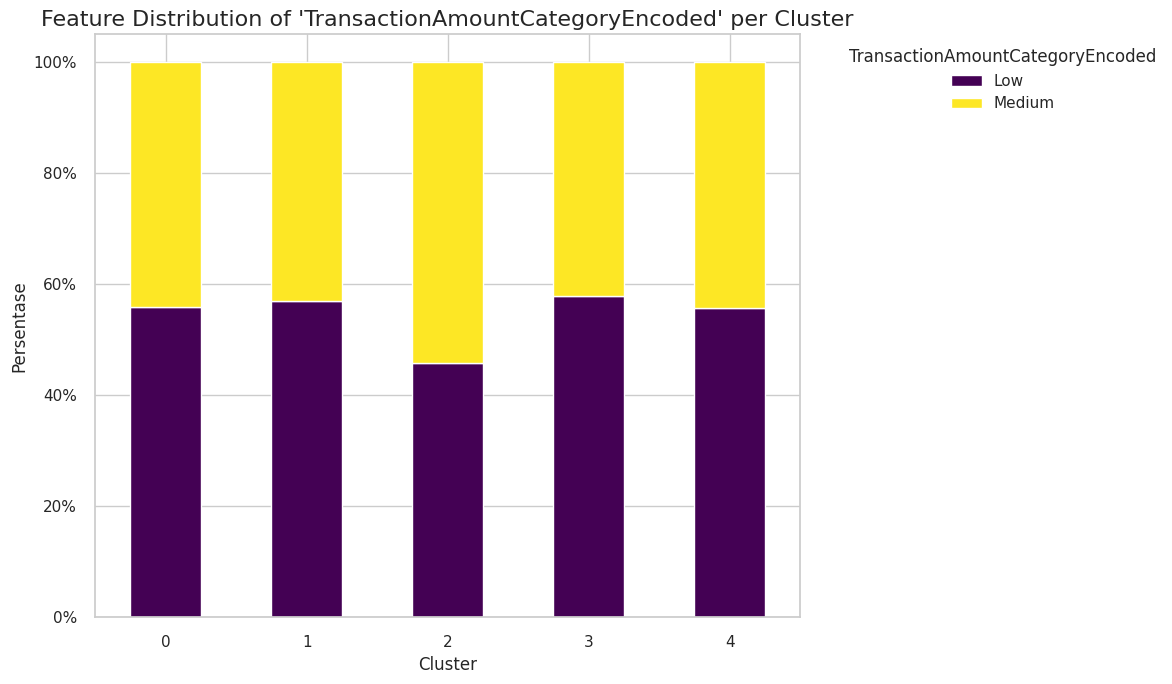

In [58]:
for col in features_categoricals_to_inverse:
  if col == 'Location':
    continue

  distribution_table = pd.crosstab(
    df_inverse['Cluster'],
    df_inverse[col],
    normalize='index'
  )

  ax = distribution_table.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 7),
    colormap='viridis'
  )

  plt.title(f"Feature Distribution of '{col}' per Cluster", fontsize=16)
  plt.xlabel('Cluster', fontsize=12)
  plt.ylabel('Persentase', fontsize=12)
  plt.xticks(rotation=0)

  ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

  plt.legend(title=col, bbox_to_anchor=(1.05, 1), loc='upper left')

  plt.tight_layout()
  plt.show()

# Exports Data Clustering

Removes the experimental PCA cluster labels and renames the primary K-Means cluster column to 'Target'. This finalizes the dataset structure for the upcoming supervised learning phase.

In [59]:
df_cluster.drop(['ClusterPCA'], axis=1, inplace=True)
df_cluster.rename(columns={'Cluster': 'Target'}, inplace=True)

Saves the fully preprocessed, scaled, and clustered dataframe as a CSV file. This data will serve as the exact training and testing ground for the classification models.

In [60]:
df_cluster.to_csv('datas/data_clustering.csv', index=False)

Cleans and exports the inverse-transformed dataset containing the original real-world values alongside their respective target labels. This is ideal for business reporting, dashboards, or external stakeholder review.

In [61]:
df_inverse.drop(['ClusterPCA'], axis=1, inplace=True)
df_inverse.rename(columns={'Cluster': 'Target'}, inplace=True)
df_inverse.to_csv('datas/data_clustering_inverse.csv', index=False)

# Data Loading Clustered

Imports the previously exported, inverse-transformed dataset into a new dataframe and previews the initial rows to confirm that the data structure and target labels are intact and ready for supervised modeling.

In [62]:
df_clustered = pd.read_csv('datas/data_clustering_inverse.csv')
df_clustered.head()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TimeSinceLastTransaction,RiskScoreLoginAmount,CustomerAgeCategoryEncoded,TransactionAmountCategoryEncoded,Target
0,14.09,Debit,San Diego,ATM,70.0,Doctor,81.0,1.0,5112.21,-49477134.0,1.881224,Older,Low,3
1,376.24,Debit,Houston,ATM,68.0,Doctor,141.0,1.0,13758.91,-42823516.0,4.112360,Older,Medium,3
2,126.29,Debit,Mesa,Online,19.0,Student,56.0,1.0,1122.35,-41694656.0,3.359316,Young,Low,4
3,184.50,Debit,Raleigh,Online,26.0,Student,25.0,1.0,8569.06,-47403415.0,3.620346,Young,Low,3
4,13.45,Credit,Atlanta,Online,45.0,Student,198.0,1.0,7429.40,-33228915.0,1.851184,Adult,Low,1


# Data Splitting

Isolates the independent predictive features (X) from the dependent cluster labels (y) to prepare the data for supervised model training.

In [63]:
X = df_clustered.drop('Target', axis=1)
y = df_clustered['Target']

Converts categorical text variables into machine-readable binary columns using `pd.get_dummies`, dropping the first category to prevent the dummy variable trap (multicollinearity).

In [64]:
X_encoded = pd.get_dummies(X, drop_first=True)

Divides the encoded dataset into training (80%) and testing (20%) sets, applying stratification to guarantee that the proportional distribution of the target classes is preserved across both splits.

In [65]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

# Model Classification

## Decision Tree

Instantiates and trains a baseline Decision Tree model on the encoded dataset, then exports the trained model artifact for future inference.

In [66]:
model_dtc = DecisionTreeClassifier(random_state=42)
model_dtc.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [67]:
joblib.dump(model_dtc, 'models/classification_decision_tree.h5')

['models/classification_decision_tree.h5']

## Random Forest

Fits an ensemble Random Forest model to improve predictive accuracy and reduce the risk of overfitting, followed by saving the model to local storage.

In [68]:
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [69]:
joblib.dump(model_rf, 'models/classification_random_forest.h5')

['models/classification_random_forest.h5']

## XGBoost

Trains a high-performance eXtreme Gradient Boosting (XGBoost) classifier to maximize predictive power and efficiency, and exports the final model.

In [70]:
model_xgb = xgb.XGBClassifier(random_state=42)
model_xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [71]:
joblib.dump(model_xgb, 'models/classification_xgboost.h5')

['models/classification_xgboost.h5']

# Evaluation

Generates predictions on the test set across all three trained models and compiles a comparative performance report evaluating their Accuracy, Precision, Recall, and weighted F1-Scores.

In [72]:
y_pred_dtc = model_dtc.predict(X_test)
y_pred_rf = model_rf.predict(X_test)
y_pred_xgb = model_xgb.predict(X_test)

comparison_reports = {
    'Decision Tree': {
        'Accuracy': accuracy_score(y_test, y_pred_dtc),
        'Precision': precision_score(y_test, y_pred_dtc, average='weighted'),
        'Recall': recall_score(y_test, y_pred_dtc, average='weighted'),
        'F1 Score': f1_score(y_test, y_pred_dtc, average='weighted')
    },
    'Random Forest': {
        'Accuracy': accuracy_score(y_test, y_pred_rf),
        'Precision': precision_score(y_test, y_pred_rf, average='weighted'),
        'Recall': recall_score(y_test, y_pred_rf, average='weighted'),
        'F1 Score': f1_score(y_test, y_pred_rf, average='weighted')
    },
    'XGBoost': {
        'Accuracy': accuracy_score(y_test, y_pred_xgb),
        'Precision': precision_score(y_test, y_pred_xgb, average='weighted'),
        'Recall': recall_score(y_test, y_pred_xgb, average='weighted'),
        'F1 Score': f1_score(y_test, y_pred_xgb, average='weighted')
    },
}

comparison_reports_df = pd.DataFrame(comparison_reports).T
comparison_reports_df

,Accuracy,Precision,Recall,F1 Score
Decision Tree,1.000000,1.000000,1.000000,1.000000
Random Forest,0.989960,0.980292,0.989960,0.985034
XGBoost,0.985944,0.986684,0.985944,0.986036


# Hyperparameter Tuning Model

Optimizes the XGBoost classifier using Grid Search Cross-Validation (`GridSearchCV`) to exhaustively find the best hyperparameter combination, and evaluates the tuned model's performance against the base models.

In [73]:
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 200, 300],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1, 0.2]
}
xgb_base = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')

gsearch_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=3,
    n_jobs=-1,
    verbose=1
)

gsearch_xgb.fit(X_train, y_train)
gsearch_xgb_best = gsearch_xgb.best_estimator_
gsearch_xgb_best

y_pred_gsearch_xgb = gsearch_xgb_best.predict(X_test)

comparison_reports_hpt = {
    'XGBoost Tuned': {
        'Accuracy': accuracy_score(y_test, y_pred_gsearch_xgb),
        'Precision': precision_score(y_test, y_pred_gsearch_xgb, average='weighted'),
        'Recall': recall_score(y_test, y_pred_gsearch_xgb, average='weighted'),
        'F1 Score': f1_score(y_test, y_pred_gsearch_xgb, average='weighted')
    },
}

comparison_reports_hpt_df = pd.DataFrame(comparison_reports_hpt).T
comparison_reports_hpt_df

Fitting 3 folds for each of 432 candidates, totalling 1296 fits


,Accuracy,Precision,Recall,F1 Score
XGBoost Tuned,0.985944,0.986684,0.985944,0.986036


Saves the final, hyperparameter-tuned XGBoost model to local storage.

In [74]:
joblib.dump(gsearch_xgb_best, 'models/classification_xgboost_tuned.h5')

['models/classification_xgboost_tuned.h5']

# Model Interpration with Explainable AI

Assigns the hyperparameter-tuned XGBoost model as the primary classifier for the interpretation and feature analysis phase.

In [75]:
model_classification = gsearch_xgb_best

Utilizes SHAP (SHapley Additive exPlanations) to calculate and visualize the global impact and directional influence of each feature across all model predictions.

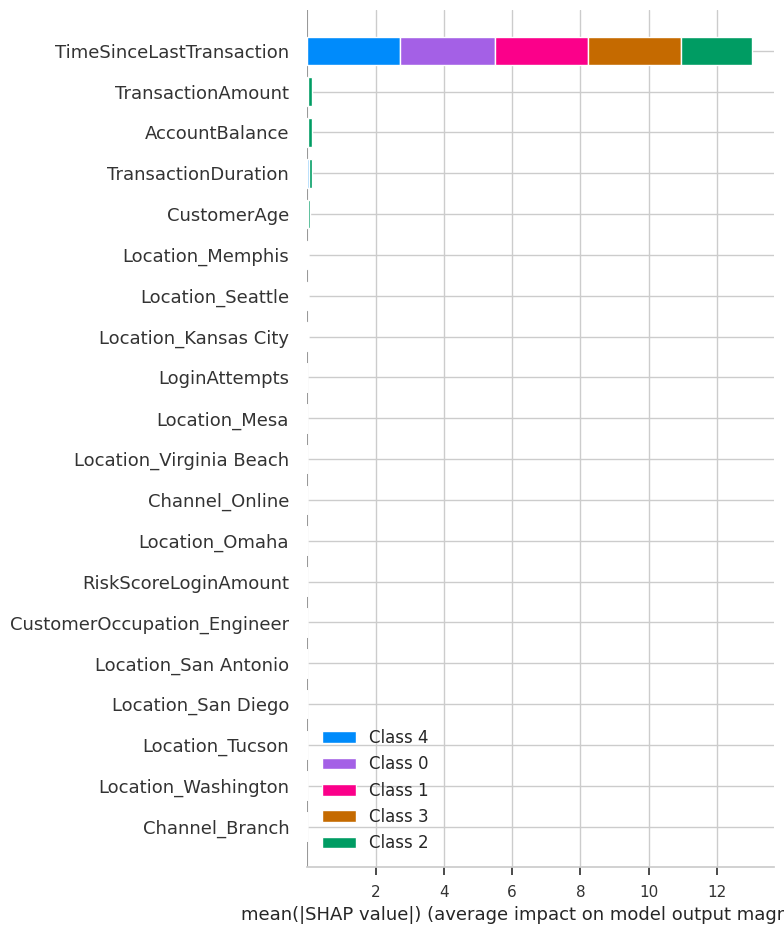

In [76]:
explainer = shap.TreeExplainer(model_classification)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, plot_type="bar")

Extracts, sorts, and visualizes the native feature importance scores from the XGBoost model to rank the variables that contribute most significantly to the internal classification splits.

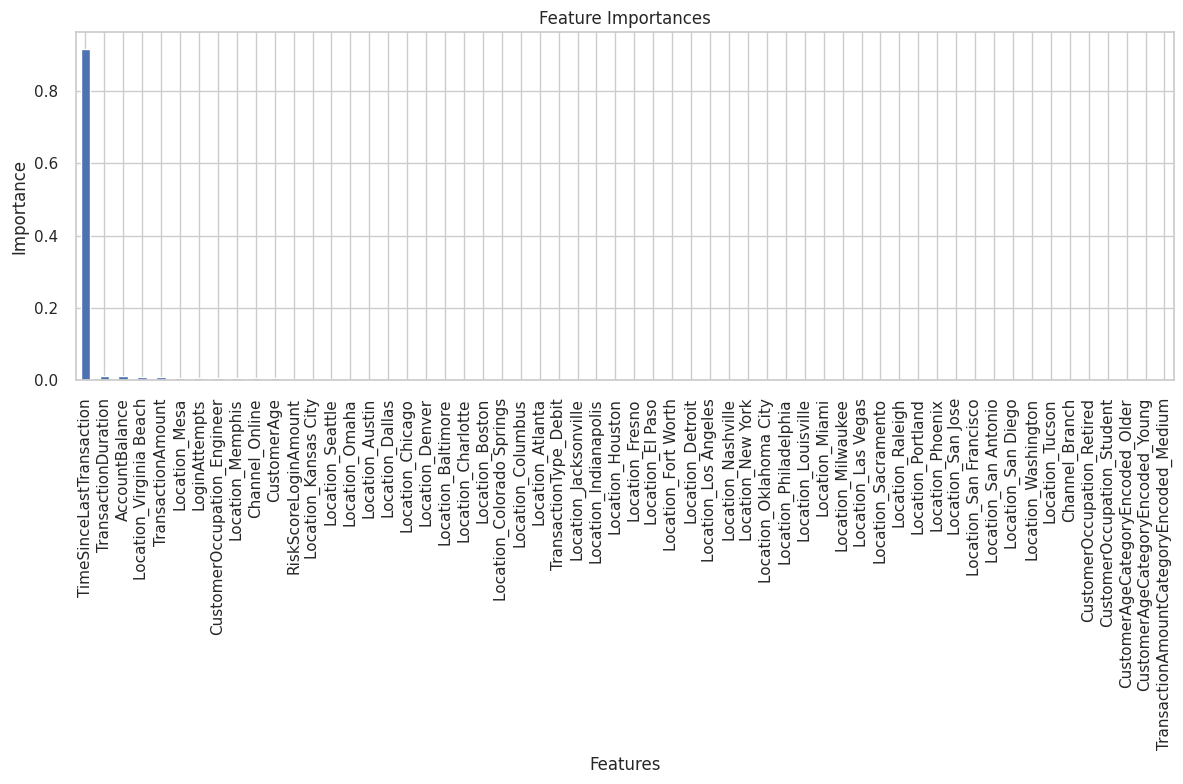

In [77]:
feature_importances = model_classification.feature_importances_
feature_importances_series = pd.Series(feature_importances, index=X_test.columns)
sorted_feature_importances = feature_importances_series.sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sorted_feature_importances.plot(kind='bar')
plt.title('Feature Importances')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Build Pipeline

## Custom Transformer

Builds a custom scikit-learn class (`FeatureEngineer`) to encapsulate and automate temporal calculations, risk scoring, data binning, and feature dropping directly within the modeling pipeline.

In [78]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        df = X.copy()
        cols_date = ['TransactionDate', 'PreviousTransactionDate']
        for col in cols_date:
            if col in df.columns:
                df[col] = pd.to_datetime(df[col])

        if 'TransactionDate' in df.columns and 'PreviousTransactionDate' in df.columns:
            df['TimeSinceLastTransaction'] = (df['TransactionDate'] - df['PreviousTransactionDate']).dt.total_seconds()
            df['TimeSinceLastTransaction'] = df['TimeSinceLastTransaction'].fillna(999999999)

        if 'LoginAttempts' in df.columns and 'TransactionAmount' in df.columns:
            df['RiskScoreLoginAmount'] = (np.log1p(df['LoginAttempts'])) * (np.log1p(df['TransactionAmount']))

        if 'CustomerAge' in df.columns:
            df['CustomerAgeCategory'] = pd.cut(df['CustomerAge'], bins=[0, 29, 59, 150], labels=['Young', 'Adult', 'Older']).astype(str)
        if 'TransactionAmount' in df.columns:
            df['TransactionAmountCategory'] = pd.cut(df['TransactionAmount'], bins=[-1, 250, 1000, 5000, float('inf')], labels=['Low', 'Medium', 'High', 'Very High']).astype(str)

        cols_to_drop = ['TransactionID', 'AccountID', 'DeviceID', 'IP Address', 'MerchantID', 'TransactionDate', 'PreviousTransactionDate']
        df = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors='ignore')
        return df

## Pipeline Tuning

Constructs a comprehensive pipeline integrating the custom feature transformer, column preprocessors (imputation, scaling, and encoding), and the XGBoost classifier. Configures Grid Search for automated hyperparameter tuning.

In [79]:
numerical_cols = ['TransactionAmount', 'CustomerAge', 'TransactionDuration', 'LoginAttempts', 'AccountBalance', 'TimeSinceLastTransaction', 'RiskScoreLoginAmount']
categorical_cols = ['Location', 'Channel', 'CustomerOccupation', 'TransactionType', 'CustomerAgeCategory', 'TransactionAmountCategory']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numerical_cols),
        ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(handle_unknown='ignore'))]), categorical_cols)
    ]
)

pipeline_base = Pipeline(steps=[
    ('engineer', FeatureEngineer()),
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier(
        random_state=42,
        use_label_encoder=False,
        eval_metric='mlogloss',
        objective='multi:softmax',
        num_class=5
    ))
])

param_grid = {
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'classifier__max_depth': [3, 5, 7],
    'classifier__n_estimators': [100, 200, 300],
    'classifier__subsample': [0.8, 1.0],
    'classifier__colsample_bytree': [0.8, 1.0],
    'classifier__gamma': [0, 0.1, 0.2]
}

print("Starting Tuning Pipeline End-to-End...")

gsearch_pipeline = GridSearchCV(
    estimator=pipeline_base,
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=3,
    n_jobs=-1,
    verbose=1
)

Starting Tuning Pipeline End-to-End...


Reloads and synchronizes the raw dataset with the cluster labels to ensure strict row alignment. Splits the unscaled data and executes the end-to-end tuning pipeline to discover the optimal parameters.

In [80]:
df_raw = pd.read_csv('datas/bank_transactions.csv')
df_clustered = pd.read_csv('datas/data_clustering.csv')

X_raw_synced = df_raw.copy()
X_raw_synced.drop_duplicates(inplace=True)
X_raw_synced.dropna(subset=['TransactionDate'], inplace=True)

X_raw_synced.reset_index(drop=True, inplace=True)
df_clustered.reset_index(drop=True, inplace=True)

y_target = df_clustered['Target']

X_raw = X_raw_synced

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y_target, test_size=0.2, random_state=42, stratify=y_target
)

gsearch_pipeline.fit(X_train_raw, y_train)

print("Tuning Done!")
print(f"Best Params: {gsearch_pipeline.best_params_}")

Fitting 3 folds for each of 432 candidates, totalling 1296 fits
Tuning Done!
Best Params: {'classifier__colsample_bytree': 1.0, 'classifier__gamma': 0, 'classifier__learning_rate': 0.01, 'classifier__max_depth': 5, 'classifier__n_estimators': 200, 'classifier__subsample': 1.0}


## Best Model Evaluation

Extracts the best estimator from the Grid Search and evaluates the fully automated pipeline's predictive performance on the unseen raw test dataset.

In [81]:
final_pipeline_tuned = gsearch_pipeline.best_estimator_

y_pred = final_pipeline_tuned.predict(X_test_raw)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

comparison_reports = {
    'Final Pipeline Tuned': {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted'),
        'Recall': recall_score(y_test, y_pred, average='weighted'),
        'F1 Score': f1_score(y_test, y_pred, average='weighted')
    },
}
print(pd.DataFrame(comparison_reports).T)

                      Accuracy  Precision    Recall  F1 Score
Final Pipeline Tuned  0.985944   0.986164  0.985944  0.985936


Serializes the complete, tuned pipeline (including all preprocessing steps and the model) into a single `.joblib` file, making it fully ready for seamless backend deployment.

In [82]:
filename = 'final_fraud_pipeline_tuned.joblib'
joblib.dump(final_pipeline_tuned, filename)

['final_fraud_pipeline_tuned.joblib']